In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = {
    'complaint_id': range(1, 16),
    'device_name': [
        'Infusion Pump','ECG Monitor','Ventilator','Infusion Pump',
        'Defibrillator','Ventilator','PIVC','Syringe','Sharp Collector',
        'IV Set','Syringe','PIVC','IV Set','Sharp Collector','PIVC'
    ],
    'product_category': [
        'Pump','Monitor','Respiratory','Pump','Cardiac','Respiratory',
        'Vascular','Injection','Safety','Infusion','Injection',
        'Vascular','Infusion','Safety','Vascular'
    ],
    'region': [
        'US','India','Germany','US','UK','India','EU','APAC',
        'Japan','US','EU','APAC','Japan','US','UK'
    ],
    'complaint_date': pd.to_datetime([
        '2025-01-10','2025-01-15','2025-02-01','2025-02-18',
        '2025-03-02','2025-03-10','2025-04-01','2025-04-22',
        '2025-05-10','2025-05-30','2025-06-14','2025-07-02',
        '2025-07-19','2025-08-05','2025-08-28'
    ]),
    'imdrf_code': [
        'A100','E200','F300','A100','E200','F300','A100','E200',
        'F300','A100','E200','F300','A100','E200','F300'
    ],
    'root_cause': [
        'Battery Failure',None,'Software Bug','User Error',
        'Electrical Issue',None,'Manufacturing Defect','User Error',
        'Manufacturing Defect',None,'Design Issue','Unknown',
        'User Error','Manufacturing Defect',None
    ],
    'closure_days': [12,8,15,6,20,11,15,7,18,30,14,6,11,22,35],
    'reportable': [
        'Yes','No','Yes','No','Yes','No','Yes','No',
        'Yes','Yes','Yes','No','No','Yes','Yes'
    ]
}


In [4]:
df = pd.DataFrame(data)
print(df.shape)
df.head()

(15, 9)


,complaint_id,device_name,product_category,region,complaint_date,imdrf_code,root_cause,closure_days,reportable
0,1,Infusion Pump,Pump,US,2025-01-10,A100,Battery Failure,12,Yes
1,2,ECG Monitor,Monitor,India,2025-01-15,E200,None,8,No
2,3,Ventilator,Respiratory,Germany,2025-02-01,F300,Software Bug,15,Yes
3,4,Infusion Pump,Pump,US,2025-02-18,A100,User Error,6,No
4,5,Defibrillator,Cardiac,UK,2025-03-02,E200,Electrical Issue,20,Yes


In [5]:
# =========================
# Task 1 — Basic EDA
# =========================

# 1. Columns and datatypes
print(df.info())

# 2. Null values per column
print(df.isnull().sum())

# 3. closure_days statistics
print("Mean:", df['closure_days'].mean())
print("Median:", df['closure_days'].median())
print("Max:", df['closure_days'].max())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   complaint_id      15 non-null     int64         
 1   device_name       15 non-null     object        
 2   product_category  15 non-null     object        
 3   region            15 non-null     object        
 4   complaint_date    15 non-null     datetime64[ns]
 5   imdrf_code        15 non-null     object        
 6   root_cause        11 non-null     object        
 7   closure_days      15 non-null     int64         
 8   reportable        15 non-null     object        
dtypes: datetime64[ns](1), int64(2), object(6)
memory usage: 1.2+ KB
None
complaint_id        0
device_name         0
product_category    0
region              0
complaint_date      0
imdrf_code          0
root_cause          4
closure_days        0
reportable          0
dtype: int64
Mean: 15.3333333333

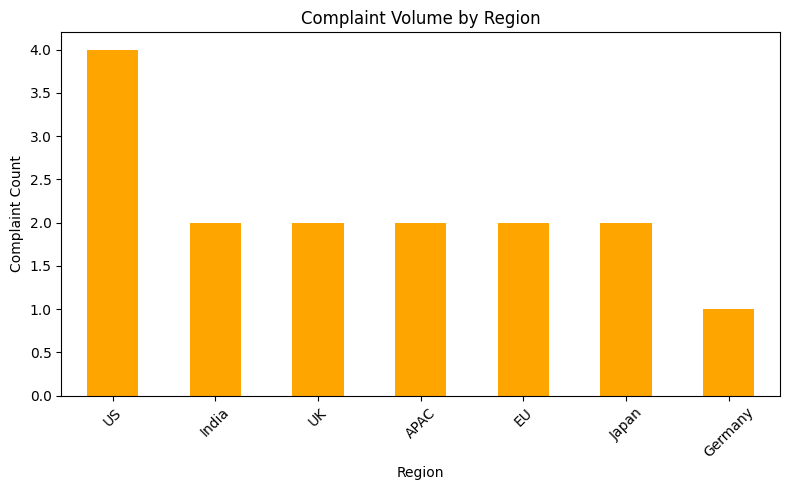

In [9]:
# =========================
# Task 2 — Complaint volume by region
# Updated Version
# =========================

region_counts = df['region'].value_counts()

plt.figure(figsize=(8,5))

region_counts.plot(
    kind='bar',
    color='orange'
)

plt.title('Complaint Volume by Region')
plt.xlabel('Region')
plt.ylabel('Complaint Count')

# Fix added
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

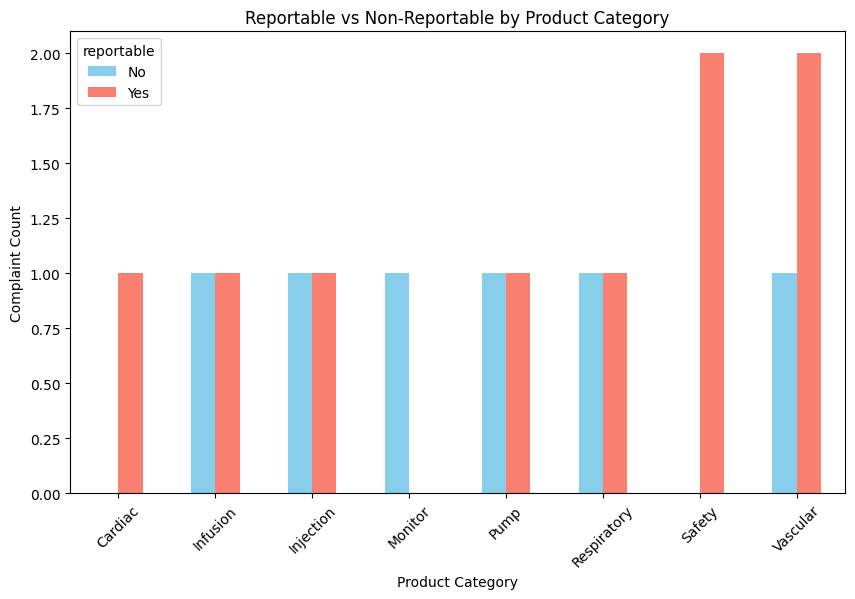

In [7]:
# =========================
# Task 3 — Reportable vs Non-Reportable
# Product Category Wise
# =========================

reportable_summary = (
    df.groupby(['product_category', 'reportable'])
      .size()
      .unstack(fill_value=0)
)

reportable_summary.plot(
    kind='bar',
    figsize=(10,6),
    color=['skyblue', 'salmon']
)

plt.title('Reportable vs Non-Reportable by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Complaint Count')

plt.xticks(rotation=45)

plt.show()

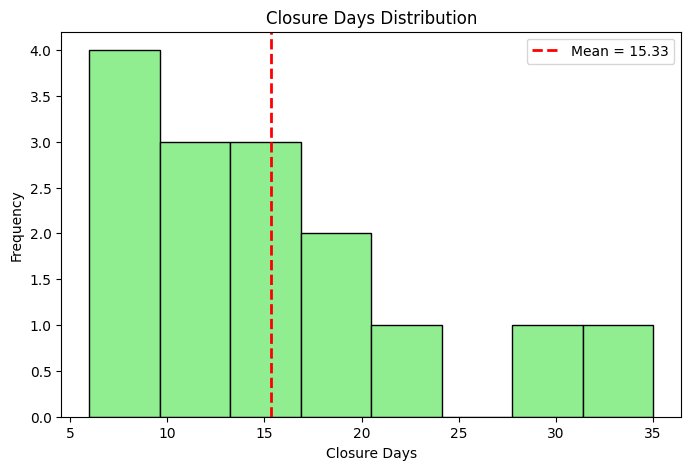

In [8]:
# =========================
# Task 4 — Closure Days Distribution
# =========================

mean_value = df['closure_days'].mean()

plt.figure(figsize=(8,5))

plt.hist(df['closure_days'], bins=8, color='lightgreen', edgecolor='black')

plt.axvline(
    mean_value,
    color='red',
    linestyle='dashed',
    linewidth=2,
    label=f'Mean = {mean_value:.2f}'
)

plt.title('Closure Days Distribution')
plt.xlabel('Closure Days')
plt.ylabel('Frequency')

plt.legend()

plt.show()